# Notebook 03 – Feature Engineering

## Objectif

Après avoir nettoyé et fusionné les données dans le Notebook 02, cette étape prépare les variables qui seront utilisées par les modèles de Machine Learning.

L'objectif est de transformer les données en un format compatible avec les algorithmes de classification tout en conservant une méthode reproductible grâce aux outils de scikit-learn.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_csv("../data/processed/insurance_clean.csv")

In [3]:
data.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmountTotal
0,1,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0
1,3,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0
2,5,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0
3,10,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0
4,11,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0


In [4]:
print("Dimensions :", data.shape)

data.info()

Dimensions : (678013, 13)
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   IDpol             678013 non-null  int64  
 1   ClaimNb           678013 non-null  int64  
 2   Exposure          678013 non-null  float64
 3   VehPower          678013 non-null  int64  
 4   VehAge            678013 non-null  int64  
 5   DrivAge           678013 non-null  int64  
 6   BonusMalus        678013 non-null  int64  
 7   VehBrand          678013 non-null  str    
 8   VehGas            678013 non-null  str    
 9   Area              678013 non-null  str    
 10  Density           678013 non-null  int64  
 11  Region            678013 non-null  str    
 12  ClaimAmountTotal  678013 non-null  float64
dtypes: float64(2), int64(7), str(4)
memory usage: 67.2 MB


In [5]:
data["HasClaim"] = (data["ClaimNb"] > 0).astype(int)

In [6]:
data["HasClaim"].value_counts()

HasClaim
0    643953
1     34060
Name: count, dtype: int64

In [7]:
(data["HasClaim"].value_counts(normalize=True) * 100).round(2)

HasClaim
0    94.98
1     5.02
Name: proportion, dtype: float64

In [8]:
data = pd.read_csv("../data/processed/insurance_clean.csv")

In [9]:
print(data.shape)
data.columns

(678013, 14)


Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region',
       'ClaimAmountTotal', 'HasClaim'],
      dtype='str')

In [10]:
features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "VehBrand",
    "VehGas",
    "Area",
    "Density",
    "Region"
]

X = data[features]
y = data["HasClaim"]

In [11]:
print("X :", X.shape)
print("y :", y.shape)

X : (678013, 10)
y : (678013,)


In [12]:
X.head()

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [13]:
numeric_features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

categorical_features = [
    "VehBrand",
    "VehGas",
    "Area",
    "Region"
]

In [14]:
print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)

Variables numériques : ['Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
Variables catégorielles : ['VehBrand', 'VehGas', 'Area', 'Region']


Identification des variables

Avant d'appliquer les transformations de prétraitement, les variables ont été séparées selon leur nature. Les variables numériques seront normalisées à l'aide de StandardScaler, tandis que les variables catégorielles seront transformées en variables numériques grâce à OneHotEncoder. Cette séparation permet d'appliquer automatiquement le traitement adapté à chaque type de donnée.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [16]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

Nous avons utilisé ColumnTransformer afin d'appliquer automatiquement un traitement différent selon le type de chaque variable. Les variables numériques sont normalisées avec StandardScaler, tandis que les variables catégorielles sont converties en variables numériques grâce à OneHotEncoder. Cette approche est plus robuste et évite les erreurs lors de l'entraînement des modèles.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (542410, 10)
X_test  : (135603, 10)
y_train : (542410,)
y_test  : (135603,)


In [19]:
print("Train (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train (%)
HasClaim
0    94.98
1     5.02
Name: proportion, dtype: float64

Test (%)
HasClaim
0    94.98
1     5.02
Name: proportion, dtype: float64


La séparation des données a été réalisée avec train_test_split en utilisant stratify=y. Cette option a permis de conserver la même proportion de contrats avec et sans sinistre dans les ensembles d'entraînement et de test (94,98 % contre 5,02 %). Cela garantit une évaluation plus fiable du modèle malgré le déséquilibre des classes.

on entraîne le premier modèle : Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

In [22]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Exposure','VehPower','VehAge',...,'Area','Density','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [23]:
y_pred = logistic_pipeline.predict(X_test)

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

In [25]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report :")
print(classification_report(y_test, y_pred))

Accuracy : 0.9498

Classification Report :
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    128791
           1       0.67      0.00      0.00      6812

    accuracy                           0.95    135603
   macro avg       0.81      0.50      0.49    135603
weighted avg       0.94      0.95      0.93    135603



In [26]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[128789,      2],
       [  6808,      4]])

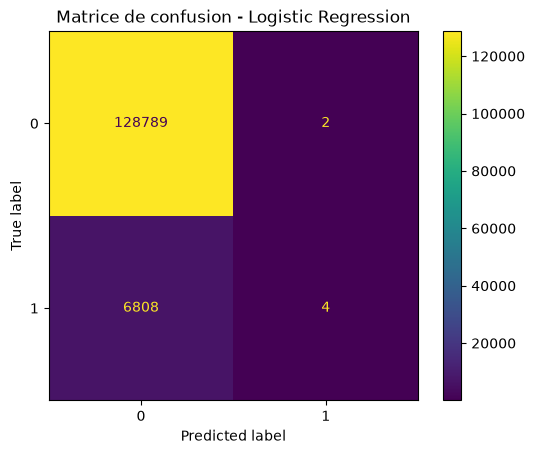

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Matrice de confusion - Logistic Regression")
plt.show()

In [28]:
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

In [29]:
roc = roc_auc_score(y_test, y_proba)
print("ROC-AUC :", round(roc, 4))

ROC-AUC : 0.6384


La régression logistique a obtenu une précision globale de 94,98 %, mais cette performance est trompeuse en raison du fort déséquilibre des classes. L'analyse de la matrice de confusion montre que le modèle détecte seulement 4 sinistres sur 6 812, ce qui conduit à un rappel presque nul pour la classe des contrats sinistrés. Le score ROC-AUC de 0,6384 indique que le modèle possède une certaine capacité à distinguer les contrats risqués, mais ses performances restent insuffisantes pour une utilisation opérationnelle sans amélioration.

In [33]:
logistic_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [34]:
logistic_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Exposure','VehPower','VehAge',...,'Area','Density','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [35]:
y_pred_balanced = logistic_balanced.predict(X_test)
y_proba_balanced = logistic_balanced.predict_proba(X_test)[:, 1]

In [36]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_balanced), 4))
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_balanced), 4))

Accuracy : 0.5813
              precision    recall  f1-score   support

           0       0.97      0.58      0.72    128791
           1       0.07      0.61      0.13      6812

    accuracy                           0.58    135603
   macro avg       0.52      0.60      0.43    135603
weighted avg       0.92      0.58      0.69    135603

[[74659 54132]
 [ 2651  4161]]
ROC-AUC : 0.6389


Une seconde version de la régression logistique a été entraînée en utilisant class_weight="balanced" afin de mieux prendre en compte le fort déséquilibre des classes (94,98 % de contrats sans sinistre contre 5,02 % avec sinistre). Cette modification a permis d'augmenter considérablement le rappel de la classe des contrats sinistrés, passant d'un niveau presque nul à environ 61 %, ce qui signifie que le modèle identifie désormais plus de six contrats risqués sur dix. En contrepartie, le nombre de faux positifs augmente fortement, ce qui réduit l'accuracy globale à 58,13 %. Cette comparaison montre qu'en assurance, une accuracy élevée n'est pas toujours le meilleur indicateur de performance, et que le rappel constitue une métrique essentielle lorsqu'il s'agit d'identifier les clients présentant un risque élevé.

## Courbe ROC de la régression logistique équilibrée

La courbe ROC permet d'évaluer la capacité du modèle à distinguer les contrats risqués des contrats sans sinistre pour différents seuils de décision.

L'aire sous la courbe (ROC-AUC) résume cette capacité :
- 0,5 : le modèle est équivalent au hasard.
- 1 : le modèle classe parfaitement les contrats.

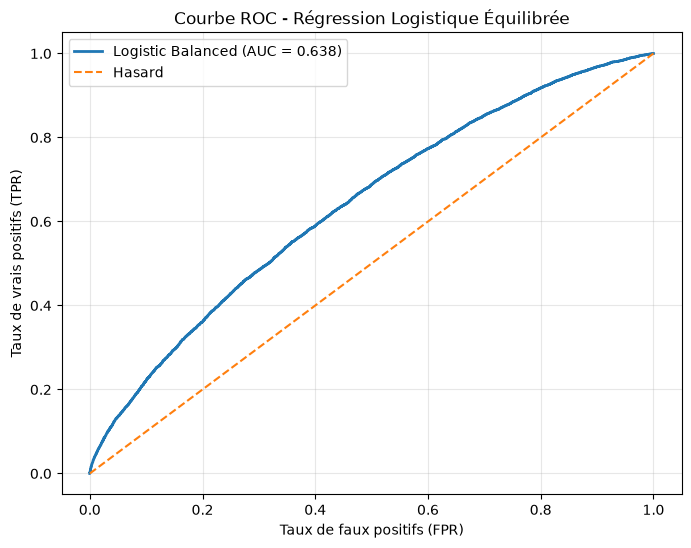

In [37]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_balanced)

# Tracé
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Balanced (AUC = {roc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Hasard")

plt.title("Courbe ROC - Régression Logistique Équilibrée")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

La courbe ROC a été utilisée pour évaluer la capacité du modèle à distinguer les contrats risqués des contrats sans sinistre pour différents seuils de décision. Le modèle obtient une aire sous la courbe (ROC-AUC) de 0,639, ce qui indique une capacité de discrimination supérieure au hasard, mais encore insuffisante pour une utilisation opérationnelle. Cette analyse confirme que la régression logistique constitue une bonne base de comparaison avant l'entraînement de modèles plus performants.